In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sbi import utils as utils
from sbi import analysis as analysis
from sbi.inference.base import infer

/Users/rutongpei/opt/anaconda3/envs/sbi_env/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [30]:
# 100 dimensions with the first number = 1 represents M_sat, other dimensions = 0

num_dim = 1
prior = utils.BoxUniform(low = 0.000001 * torch.ones(num_dim), high = 1 * torch.ones(num_dim))

In [58]:
def simple_relation(positions, M_sat):
    
    for i in range(0, 9, 2):
        positions[i]= positions[i]  * M_sat[0]
        positions[i+1] =  positions[i+1] * M_sat[0]
    
    return torch.as_tensor(positions)

In [59]:
def simulator(M_sat):
    initial_positions = [-1.8138866826403834, 0.8954823881221083, 1.7566761503756605, 0.8789342222078965, -1.8006901742697587, 0.9494161353346301, 0.9081439200380186, 0.7635219430817995, -0.008181655431905905, 0.796561786910262, -0.21691681326121745, 0.8579657003715206, -0.09761778951794295, 0.8777781890395303, 0.05736985631605306, 0.800689000744381, -0.5823427366851369, 0.9919817754090198, 0.7809385547510916, 0.6980474647857187]
    
    return simple_relation(initial_positions, M_sat)

In [57]:
# calculate the expected observation values 
# positions = [-1.8138866826403834, 0.8954823881221083, 1.7566761503756605, 0.8789342222078965, -1.8006901742697587, 0.9494161353346301, 0.9081439200380186, 0.7635219430817995, -0.008181655431905905, 0.796561786910262, -0.21691681326121745, 0.8579657003715206, -0.09761778951794295, 0.8777781890395303, 0.05736985631605306, 0.800689000744381, -0.5823427366851369, 0.9919817754090198, 0.7809385547510916, 0.6980474647857187]
# M_sat = [0.5]
# for i in range(0, 9, 2):
#         positions[i]= positions[i] * M_sat[0]
#         positions[i+1] =  positions[i+1] * M_sat[0]
# print(positions)

[-0.9069433413201917, 0.44774119406105417, 0.8783380751878302, 0.43946711110394826, -0.9003450871348794, 0.47470806766731505, 0.4540719600190093, 0.3817609715408998, -0.004090827715952952, 0.398280893455131, -0.21691681326121745, 0.8579657003715206, -0.09761778951794295, 0.8777781890395303, 0.05736985631605306, 0.800689000744381, -0.5823427366851369, 0.9919817754090198, 0.7809385547510916, 0.6980474647857187]


In [60]:
posterior = infer(simulator, prior, "SNLE", num_simulations=100)


Running 100 simulations.: 100%|██████████| 100/100 [00:00<00:00, 8088.06it/s]


 Neural network successfully converged after 1686 epochs.

In [61]:
observation1 = [-0.9069433413201917, 0.44774119406105417, 0.8783380751878302, 0.43946711110394826, -0.9003450871348794, 0.47470806766731505, 0.4540719600190093, 0.3817609715408998, -0.004090827715952952, 0.398280893455131, -0.21691681326121745, 0.8579657003715206, -0.09761778951794295, 0.8777781890395303, 0.05736985631605306, 0.800689000744381, -0.5823427366851369, 0.9919817754090198, 0.7809385547510916, 0.6980474647857187]
observation2=[1.2]

Generating samples: 100%|██████████| 1100/1100 [01:12<00:00, 15.26it/s]


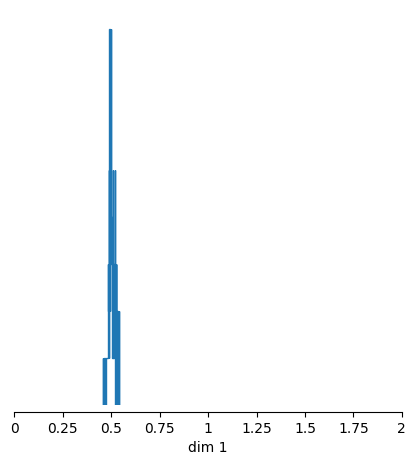

In [62]:
posterior_samples_1 = posterior.sample((100,), x=observation1)

# plot posterior samples
_ = analysis.pairplot(
    posterior_samples_1, limits=[[0,2]], figsize=(5, 5)
)


In [44]:
posterior_samples_2 = posterior.sample((100,), x=observation2)

# plot posterior samples
_ = analysis.pairplot(
    posterior_samples_2, limits=[[0,2]], figsize=(5, 5)
)

AssertionError: Observed data shape (torch.Size([1])) must match the shape of simulated data x (torch.Size([20])).

with constant perturbation strength lines

/Users/rutongpei/opt/anaconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:17: RuntimeWarning: divide by zero encountered in true_divide
  app.launch_new_instance()
/Users/rutongpei/opt/anaconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:21: RuntimeWarning: divide by zero encountered in true_divide
/Users/rutongpei/opt/anaconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:24: RuntimeWarning: divide by zero encountered in true_divide
/Users/rutongpei/opt/anaconda3/envs/sbi_env/lib/python3.7/site-packages/ipykernel_launcher.py:27: RuntimeWarning: divide by zero encountered in true_divide


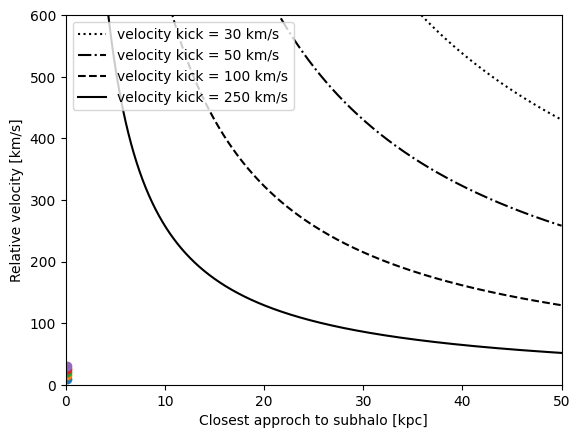

6.67e-11 2.985e+41 3.086e+20 30000.0


In [71]:
G=6.67e-11
M= 15 # mass of subhalo in 1e10 Msun
#b= impact parameter in kpc
#w= relative velocity in km/s

#delta_v in km/s
delta_v1= 30
delta_v2= 50
delta_v3= 100
delta_v4= 250

# x axis: cloest approach to subhalo, i.e. impact parameter b
# y axis: relative velocity at cloest approach, w


b = np.arange(0.0, 50.0, 0.01)
w1 = G*(M*1.99e40)/(b*3.086e19)/(delta_v1*1e3)/1e3
plt.plot(b,w1, label='velocity kick = 30 km/s', linestyle='dotted', color='black')


w2 = G*(M*1.99e40)/(b*3.086e19)/(delta_v2*1e3)/1e3
_ = plt.plot(b,w2, label='velocity kick = 50 km/s', linestyle='-.', color='black')

w3 = G*(M*1.99e40)/(b*3.086e19)/(delta_v3*1e3)/1e3
_ = plt.plot(b,w3, label='velocity kick = 100 km/s', linestyle='--', color='black')

w4 = G*(M*1.99e40)/(b*3.086e19)/(delta_v4*1e3)/1e3
_ = plt.plot(b,w4, label='velocity kick = 250 km/s', color='black')

plt.legend()
plt.xlim(0, 50)
plt.ylim(0, 600)
plt.xlabel("Closest approch to subhalo [kpc]")
plt.ylabel("Relative velocity [km/s]")


# stream models as dots
x=[0.1,0.1,0.1,0.1,0.1]
y=[10,15,20,25,30]
for i in range(5):
    plt.plot(x[i],y[i],'o')

plt.show()
print(G, (M*1.99e40), (10*3.086e19), (delta_v1*1e3))